Script to generate plots of DEMs used for lapse-rate based downscaling. Plot is shown as Figure C1 in appendix C of the revised manuscript.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import xarray as xr
import platform
import cartopy.crs as ccrs
import cartopy.io.shapereader as shapereader
import rioxarray
import warnings
warnings.filterwarnings("ignore")

if platform.system() == 'Windows':
    base_dir = Path('L:\malle\CLM5_CH')
else:
    base_dir = Path('/home/lud11/malle/CLM5_CH')

First load data and plot essentials:

In [3]:
dem_file = base_dir / 'BAFU_DEM_2020_1000.txt'
dem_array = rioxarray.open_rasterio(dem_file, parse_coordinates=True, masked=True)
dem_data_HR = dem_array.squeeze()
input_highres = xr.open_dataset(base_dir / 'surfdata_1km_CH_v3_hist_16pfts_Irrig_CMIP6_NEW.nc')
lat_geo = input_highres.LATIXY[:, 0]
lon_geo = input_highres.LONGXY[0, :]
da = xr.DataArray(data=np.flipud(dem_data_HR.data), coords=[("lat", lat_geo.data),("lon", lon_geo.data)])
dem_data_HR = xr.Dataset(data_vars={"TOPO": da})

dem_data_LR = xr.open_dataset(base_dir / 'topodata_360x720_c060528.nc')
surf_05deg = xr.open_dataset(base_dir / 'surfdata_CH_05deg_v2_hist_16pfts_Irrig_CMIP6_simyr2000_c230113.nc')
lat_geo = surf_05deg.LATIXY[:, 0]
lon_geo = surf_05deg.LONGXY[0, :]
lat_geo = dem_data_LR.LATIXY[:, 0]
lon_geo = dem_data_LR.LONGXY[0, :]
dem_data_LR = dem_data_LR.assign_coords({'lsmlon': lon_geo.data, 'lsmlat': lat_geo.data})

countries = shapereader.natural_earth(resolution='10m', category='cultural', name='admin_0_countries')
for country in shapereader.Reader(countries).records():
    if 'Switzerland' in country.attributes['NAME_EN']:
        switzerland = country.geometry
        break
else:
    raise ValueError('Unable to find the CH boundary.')

now generate plot:

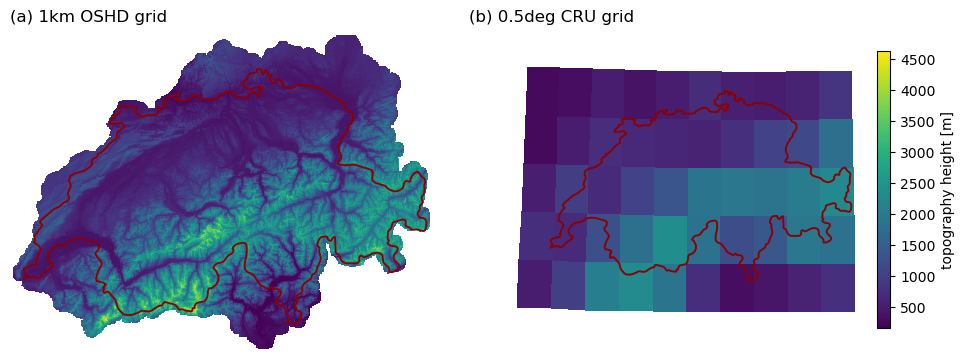

In [4]:
min_lat, max_lat = surf_05deg.LATIXY.min().data, surf_05deg.LATIXY.max().data
min_lon, max_lon = surf_05deg.LONGXY.min().data, surf_05deg.LONGXY.max().data
mask = ((dem_data_LR.LATIXY<=max_lat) & (dem_data_LR.LATIXY>=min_lat) & (dem_data_LR.LONGXY<=max_lon) & (dem_data_LR.LONGXY>=min_lon))
lat_in = np.where(mask ==True)[0]
lon_in = np.where(mask ==True)[1]

min_all = np.min([np.nanmin(dem_data_HR.TOPO.data), np.nanmin(dem_data_LR.TOPO[lat_in[0]:lat_in[-1]+1,lon_in[0]-1:lon_in[-1]+1].data)])
max_all = np.max([np.nanmax(dem_data_HR.TOPO.data), np.nanmax(dem_data_LR.TOPO[lat_in[0]:lat_in[-1]+1,lon_in[0]-1:lon_in[-1]+1].data)])

proj_data = ccrs.PlateCarree()
proj_map = ccrs.UTM(zone=32, southern_hemisphere=False)

fig1 = plt.figure(figsize=[12, 6])
ax1 = plt.subplot(121, projection=proj_map)
ax2 = plt.subplot(122, projection=proj_map)
dem_data_HR.TOPO.plot(ax=ax1, transform=proj_data, vmin=min_all, vmax=max_all, add_colorbar=False)
ax1.add_geometries([switzerland], ccrs.Geodetic(), edgecolor='darkred', linewidth=1.35, facecolor='none')
ax1.axis('off')
dem_data_LR.TOPO[lat_in[0]:lat_in[-1]+1,lon_in[0]-1:lon_in[-1]+1].plot(ax=ax2, transform=proj_data, vmin=min_all, vmax=max_all, cbar_kwargs={'shrink':0.6})
ax2.add_geometries([switzerland], ccrs.Geodetic(), edgecolor='darkred', linewidth=1.35, facecolor='none')
ax2.axis('off')
ax1.set_title('(a) 1km OSHD grid', fontsize=12, loc='left')
ax2.set_title('(b) 0.5deg CRU grid', fontsize=12, x=0.1, y=1.15)
fig1.savefig(base_dir / 'figures_revisions' / 'dem_comp.png', facecolor='white', transparent=False, bbox_inches='tight')